### Face Detection using OpenCV Haar Cascades

We will use OpenCV's built-in Haar Cascade classifiers for face detection. These are pre-trained models that can quickly detect various objects, including faces, in images.

**Steps:**
1.  **Load the Classifier:** Load the pre-trained Haar Cascade XML file for frontal face detection.
2.  **Load an Image:** Read an image from a file.
3.  **Grayscale Conversion:** Convert the image to grayscale, as Haar Cascades work best with grayscale images.
4.  **Detect Faces:** Apply the classifier to the grayscale image to detect faces.
5.  **Draw Bounding Boxes:** Draw rectangles around the detected faces on the original color image.
6.  **Display Result:** Show the image with detected faces.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Download the Haar Cascade classifier for frontal face detection
# This file is usually located in the opencv-python package or can be downloaded from the OpenCV GitHub
# For simplicity, we'll try to use a common path or suggest manual download if not found.

try:
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    if face_cascade.empty():
        raise IOError('Could not load face cascade classifier.')
    print("Haar Cascade classifier loaded successfully.")
except Exception as e:
    print(f"Error loading Haar Cascade classifier: {e}")
    print("Please ensure 'haarcascade_frontalface_default.xml' is available.")
    print("You might need to download it manually from https://github.com/opencv/opencv/blob/master/data/haarcascades/haarcascade_frontalface_default.xml")
    print("and place it in the same directory as this notebook, or provide its full path.")
    face_cascade = None

Haar Cascade classifier loaded successfully.


For demonstration, I'll use a sample image. If you have your own image, upload it to your Colab environment and replace `'sample_image.jpg'` with your image path.

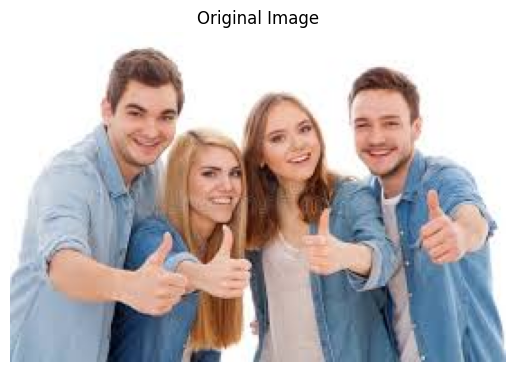

Image loaded and converted to grayscale.


In [2]:
# Load the image
# You can upload an image by clicking the folder icon on the left panel, then 'Upload to session storage'.

image_path = '/content/huma image.jpeg'

image = cv2.imread(image_path)

if image is None:
    print(f"Error: Could not load image from {image_path}. Please check the path and file.")
else:
    # Convert to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Display the original image
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    print("Image loaded and converted to grayscale.")

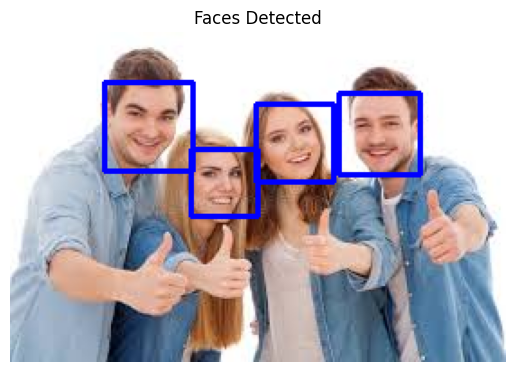

Detected 4 face(s).


In [3]:
if face_cascade is not None and image is not None:
    # Detect faces in the image
    # The detectMultiScale function detects objects of different sizes in the input image.
    # The detected objects are returned as a list of rectangles.
    # Parameters:
    # 1. image: The grayscale image.
    # 2. scaleFactor: Parameter specifying how much the image size is reduced at each image scale.
    #    (e.g., 1.1 means reducing the size by 10% each time).
    # 3. minNeighbors: Parameter specifying how many neighbors each candidate rectangle should have to retain it.
    # 4. minSize: Minimum possible object size. Objects smaller than that are ignored.
    faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Draw rectangles around the faces
    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue rectangle, thickness 2

    # Display the image with detected faces
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Faces Detected")
    plt.axis('off')
    plt.show()

    print(f"Detected {len(faces)} face(s).")
else:
    print("Face detection could not proceed due to missing cascade classifier or image.")